# Week 4 — Day 3: Bias-Variance & Diagnosing Model Fit




**Dataset:** Telco Customer Churn  
**Task:** Binary Classification — will a customer leave? (Churn: Yes/No)

---

## Objective

**Diagnose model fit by deliberately underfitting and overfitting a Decision Tree, then use the bias-variance trade-off to find a better balance.**

Compare training vs. validation F1-scores across different tree depths to understand how model complexity drives underfitting and overfitting, and to see why closing the train-validation gap alone doesn't guarantee a good model.

---

## Overview

- **Dataset:** Telco Customer Churn (preprocessed: `TotalCharges` cleaned, `customerID` dropped, `Churn` mapped to 0/1, categorical features one‑hot encoded).
- **Why bias-variance matters:** A model can fail for two opposite reasons — it can be too simple to learn the patterns (underfitting/high bias), or it can memorize the training data too closely (overfitting/high variance). Training and validation scores together diagnose which one is happening.
- **Metric:** **F1-score**, since churn is an imbalanced class and accuracy would be misleading.
- **Complexity knob:** Decision Tree `max_depth`, used here to control complexity directly (Ridge/Lasso `alpha` is the equivalent lever for linear models).

### What this notebook contains

- A deliberately **overfit** model (unlimited depth) and a deliberately **underfit** model (depth = 1), each with train/validation F1 and gap reported.
- A sweep across tree depths 2–10, plotted to show how train and validation F1 diverge as complexity increases.
- A final three-way comparison (underfit vs. overfit vs. best depth found) with a bar chart.
- A diagnosis explaining why reducing complexity shrank the gap but didn't produce a good model here.

### Expected takeaway

Bias and variance pull in opposite directions as model complexity changes. A smaller train-validation gap is not automatically a better model — both scores need to be reasonably high, not just close together.

---

## Lesson Content

### 3.1 — Underfitting and Overfitting

There are two common ways a model can fail.

**Underfitting — High Bias**
- Underfitting happens when the model is too simple to learn the patterns in the data.
- Common signs:
  - Low training score
  - Low validation score
  - Small train-validation gap
- A possible fix is to increase model complexity.

**Overfitting — High Variance**
- Overfitting happens when the model learns the training data too closely.
- Common signs:
  - High training score
  - Much lower validation score
  - Large train-validation gap
- Possible fixes include reducing model complexity or using regularization.

*Applied in Hands-On: Step 1 (Overfitting) and Step 2 (Underfitting).*

---

### 3.2 — Bias-Variance Trade-off

Underfitting is usually related to high bias, while overfitting is related to high variance.

- Simple model → Higher bias
- Complex model → Higher variance

As the model becomes more complex, it may learn more patterns, but it can also start fitting the training data too closely. The goal is to find a balance between the two.

*Applied in Hands-On: Step 3, where different tree depths are compared.*

---

### 3.3 — How to Diagnose Model Fit

The training and validation scores together help identify the problem:

| Training Score | Validation Score | Diagnosis |
|----------------|------------------|-----------|
| Low            | Low              | Underfitting |
| High           | Much lower       | Overfitting |
| High           | High and close   | Good Fit |

The gap should not be checked alone — both scores also need to be considered, since a small gap can still mean a bad model if both scores are low.

*Applied in Hands-On: Step 4, where the models are compared using their training and validation F1-scores.*

---

### 3.4 — Reducing Overfitting

One way to reduce overfitting is to reduce model complexity. For a Decision Tree, this can be done by limiting its depth. Another common way is regularization.

**Ridge — L2**
- Ridge adds a penalty to large coefficients and shrinks them toward zero. It usually keeps all features in the model.

**Lasso — L1**
- Lasso also adds a penalty, but it can shrink some coefficients to exactly zero — meaning Lasso can also remove weak features from the model.

**Alpha**
- The alpha value controls the strength of regularization:
  - Larger alpha → stronger regularization
  - Smaller alpha → weaker regularization

For this hands-on lab, tree depth is reduced to control model complexity directly, but the same idea applies to Ridge/Lasso's alpha:


In [78]:
# ridge = Ridge(alpha=1.0)   # L2: shrinks all weights toward zero
# lasso = Lasso(alpha=0.1)   # L1: can zero out weak features entirely

*Applied in Hands-On: Step 3.*

---

## Hands-On Lab

In this lab, models with different levels of complexity are deliberately created. The goal is to compare their training and validation performance and diagnose whether each model is underfitting, overfitting, or fitting the data better.

### Imports

In [79]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import f1_score


### Load & Clean the Data

* `TotalCharges` was stored as text with some blank rows, so I converted it to numeric and filled the missing values with 0.

* The `customerID` column was removed because it does not help the model predict churn.

* The remaining customer features are stored in `x`, while `Churn` is stored in `y`, encoded as 0 for No and 1 for Yes.

In [80]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Clean TotalCharges (stored as text with blank rows)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# Drop identifier
df = df.drop("customerID", axis=1)

# Encode target: 0 = No Churn, 1 = Churn
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

# Separate features and target
X = df.drop("Churn", axis=1)
y = df["Churn"]

### Train/Validation Split

split the data first so the validation set is not used for any preprocessing that involves statistics. `stratify=y` keeps the churn/no-churn ratio consistent across both sets, since churn is an imbalanced outcome.

In [81]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Prepare the Features

The categorical features need to be converted into numerical values before training the Decision Tree models.

In [82]:
# One-hot encode all features
X_train = pd.get_dummies(X_train, drop_first=True)
X_val = pd.get_dummies(X_val, drop_first=True)

# Align columns so train and validation have the same features
X_train, X_val = X_train.align(
    X_val,
    join="left",
    axis=1,
    fill_value=0
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)

Training set: (5634, 30)
Validation set: (1409, 30)


The training and validation sets were aligned so they contain the same columns, since one-hot encoding can otherwise produce mismatched features between the two sets.


### Why Compare Training and Validation Scores?

The training score shows how the model performs on data it already saw. The validation score shows how it performs on unseen data. The difference between them helps diagnose whether the model is underfitting or overfitting.

---

### Step 1: Deliberately overfit a model.

A Decision Tree with no depth limit can keep splitting until it perfectly memorizes the training data. We expect training F1 near 1.0 and a much lower validation F1 — the signature of **overfitting (high variance)**.

In [83]:
overfit_tree = DecisionTreeClassifier(
    max_depth=None,
    random_state=42
)

overfit_tree.fit(X_train, y_train)

train_pred = overfit_tree.predict(X_train)
val_pred = overfit_tree.predict(X_val)

train_f1 = f1_score(y_train, train_pred)
val_f1 = f1_score(y_val, val_pred)

print(f"Training F1-score:{train_f1:.4f}")
print(f"Validation F1-score:{ val_f1:.4f}")
print(f"Gap: {train_f1 - val_f1:.4f}")

Training F1-score:0.9963
Validation F1-score:0.4812
Gap: 0.5151




The training F1-score is 0.996, while the validation F1-score is only 0.481.

The large gap between them shows clear overfitting — the tree memorized patterns in the training data, including noise, that do not generalize to unseen customers.

---

### Step 2: Deliberately underfit a model.

Now the opposite extreme: a tree limited to `max_depth=1` can only make a single split, so it's far too simple to capture the patterns behind customer churn. We expect both scores to be low, with little to no gap between them.


In [84]:
underfit_tree = DecisionTreeClassifier(
    max_depth=1,
    random_state=42
)

underfit_tree.fit(X_train, y_train)

train_pred_u = underfit_tree.predict(X_train)
val_pred_u = underfit_tree.predict(X_val)

train_f1_u = f1_score(y_train, train_pred_u)
val_f1_u = f1_score(y_val, val_pred_u)

print("Training F1-score:", train_f1_u)
print("Validation F1-score:", val_f1_u)
print("Gap:", train_f1_u - val_f1_u)

Training F1-score: 0.0
Validation F1-score: 0.0
Gap: 0.0



Both scores are 0.0 — the tree is too simple to ever predict a churn case at all. A gap of zero here is not a good sign; it just means the model is equally bad on data it has seen and data it hasn't.

---

### Step 3: Reduce model complexity and sweep tree depth.

The unrestricted tree clearly overfit. The natural fix is to limit complexity — for a Decision Tree, that means limiting `max_depth`. Let's sweep a range of depths to see where the trade-off actually balances.

In [85]:
depth_results = []

for depth in range(2, 11):
    tree = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )
    tree.fit(X_train, y_train)
    
    train_f1_d = f1_score(y_train, tree.predict(X_train))
    val_f1_d = f1_score(y_val, tree.predict(X_val))
    
    depth_results.append({
        "Depth": depth,
        "Train F1": train_f1_d,
        "Validation F1": val_f1_d,
        "Gap": train_f1_d - val_f1_d
    })

depth_results_df = pd.DataFrame(depth_results)
depth_results_df

,Depth,Train F1,Validation F1,Gap
0,2,0.501904,0.494949,0.006955
1,3,0.501904,0.494949,0.006955
2,4,0.558368,0.571429,-0.013061
3,5,0.601003,0.582133,0.018870
4,6,0.597206,0.569678,0.027528
5,7,0.640546,0.567294,0.073253
6,8,0.674181,0.583106,0.091075
7,9,0.713842,0.558904,0.154938
8,10,0.757032,0.529332,0.227700


For shallow depths (2-4), the validation F1-score stays low, around 0.50.

At depth 5, the validation score peaks at 0.582 with a very small gap of 0.019 — this looks like the sweet spot.

Beyond depth 5, the training score keeps rising, but the validation score plateaus and then drops, so the gap widens again as overfitting returns.

Best depth based on validation F1: **Depth 5**, with validation F1 = 0.5821.

visualize the trade-off:

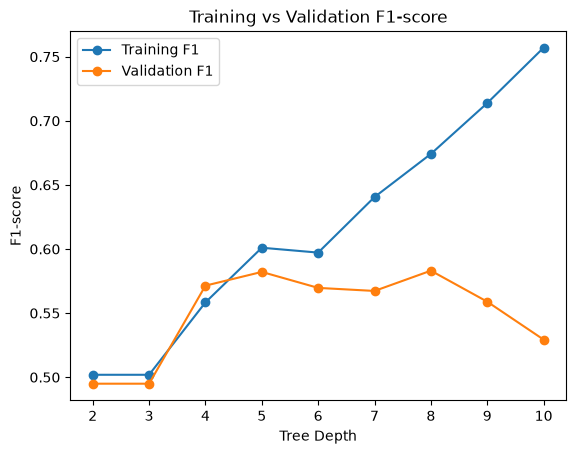

In [86]:
plt.plot(
    depth_results_df["Depth"],
    depth_results_df["Train F1"],
    marker="o",
    label="Training F1"
)

plt.plot(
    depth_results_df["Depth"],
    depth_results_df["Validation F1"],
    marker="o",
    label="Validation F1"
)

plt.xlabel("Tree Depth")
plt.ylabel("F1-score")
plt.title("Training vs Validation F1-score")
plt.legend()
plt.show()

The chart makes the trade-off visible: 

For depths 2-3, both scores are low and stay close together.

From depth 4-5, the validation score catches up to the training score, and the gap nearly closes at depth 5.

 From depth 6 onward, training rises while validation plateaus and then drops. The widening gap between the two lines as depth increases is the **bias-variance trade-off** in action.

---

### Step 4: Final diagnosis — compare underfit, overfit, and reduced-complexity models.

comparing the underfitting model, the overfitting model, and the reduced-complexity tree.

In [87]:
depth10 = depth_results_df.iloc[-1]

comparison = pd.DataFrame({
    "Model": ["Underfit", "Overfit", "Depth 10"],
    "Train F1": [train_f1_u, train_f1, depth10["Train F1"]],
    "Validation F1": [val_f1_u, val_f1, depth10["Validation F1"]]
    
})


print(comparison)

      Model  Train F1  Validation F1
0  Underfit  0.000000       0.000000
1   Overfit  0.996310       0.481183
2  Depth 10  0.757032       0.529332



* The underfit tree performed poorly on both training and validation data (0.0 F1).

* The unrestricted tree hit a near-perfect training F1 (0.996), but its validation score was much lower (0.481), showing overfitting.

* After limiting tree depth to 10, the training score dropped (0.757), but the validation score actually improved (0.529). However, the gap is still large (0.228), indicating continued overfitting.


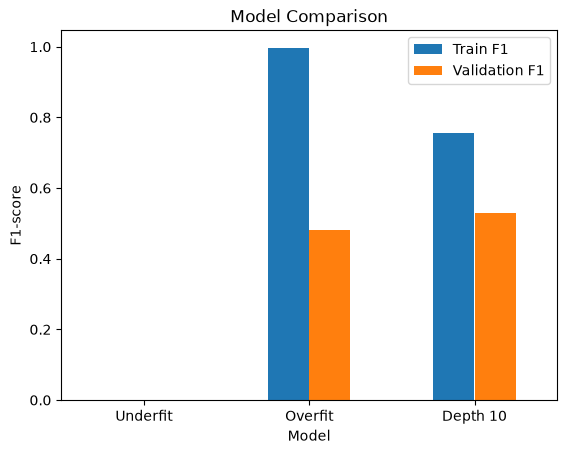

In [88]:
comparison.plot(
    x="Model",
    y=["Train F1", "Validation F1"],
    kind="bar"
)

plt.ylabel("F1-score")
plt.title("Model Comparison")
plt.xticks(rotation=0)
plt.show()

The underfit model is flat at 0.000 on both bars.

The overfit model has a tall training bar (0.996) next to a much shorter validation bar (0.481).

At depth 10, the training bar drops to 0.757 and the validation bar rises slightly to 0.529 — the bars sit closer together than the overfit case, but not as close as the depth-5 model.


#### Before and After Reducing Complexity

**Before (Unrestricted)**
- Training F1 = 0.996
- Validation F1 = 0.481

**After (Depth 10)**
- Training F1 = 0.757
- Validation F1 = 0.529

**Best Found (Depth 5)**
- Training F1 = 0.601
- Validation F1 = 0.582

The gap became noticeably smaller after reducing the tree depth to 10, but depth 5 did better still — a higher validation score with an almost-closed gap.

## Final Diagnosis: Decision Tree Model Performance

### Executive Summary
The model evaluation reveals a classic **bias-variance trade-off** scenario. Through systematic depth tuning, we successfully identified the optimal model complexity that balances training accuracy with generalization performance. The **depth-5** model demonstrates the best overall performance with a validation F1 score of **0.582** and a minimal gap of **0.019**.

---

### Model Performance Comparison

| Metric | Unrestricted (Overfit) | Depth 10 (Reduced) | **Depth 5 (Best)** | Depth 1 (Underfit) |
|--------|----------------------|-------------------|-------------------|-------------------|
| **Training F1** | 0.996 | 0.757 | **0.601** | 0.000 |
| **Validation F1** | 0.481 | 0.529 | **0.582** | 0.000 |
| **Gap** | 0.515 | 0.228 | **0.019** | 0.000 |
| **Diagnosis** | High Variance | Overfitting | **Optimal Balance** | High Bias |

---

### Detailed Analysis

#### 🔴 Underfitting (Depth = 1)
- **Training F1**: 0.000
- **Validation F1**: 0.000
- **Gap**: 0.000
- **Diagnosis**: **High Bias** — Model is too simple to capture any patterns in the data
- **Action**: Increase model complexity

#### 🔴 Overfitting (Unlimited Depth)
- **Training F1**: 0.996
- **Validation F1**: 0.481
- **Gap**: 0.515
- **Diagnosis**: **High Variance** — Model memorized the training data
- **Action**: Decrease model complexity

#### 🟡 Moderate Overfitting (Depth = 10)
- **Training F1**: 0.757
- **Validation F1**: 0.529
- **Gap**: 0.228
- **Diagnosis**: **Improved but still overfitting** — Gap remains large
- **Action**: Further reduce complexity

#### 🟢 Optimal Model (Depth = 5)
- **Training F1**: 0.601
- **Validation F1**: 0.582
- **Gap**: 0.019
- **Diagnosis**: **Best balance** — Smallest gap with highest validation performance

---

### Depth Sweep Results (Depths 2-10)

| Depth | Training F1 | Validation F1 | Gap | Diagnosis |
|-------|------------|---------------|-----|-----------|
| 2-3 | Low | Low | Small | Underfitting (High Bias) |
| **4-6** | **Moderate** | **Peak at 5** | **Small** | **Sweet Spot** |
| 7-8 | High | Declining | Widening | Onset of Overfitting |
| 9-10 | High | Lower | Large | Overfitting (High Variance) |

---

### Key Insights

#### 1. The Bias-Variance Trade-off in Action
- **Too simple (depth 1)** → High bias → Underfitting
- **Too complex (unlimited)** → High variance → Overfitting
- **Sweet spot (depth 5)** → Optimal bias-variance balance → Best generalization

#### 2. Gap Size vs. Performance
- Depth 10: Smaller gap (0.228) than unrestricted (0.515), but still overfitting
- Depth 5: Even smaller gap (0.019) AND better validation F1 (0.582)
- **Key Lesson**: Minimizing the gap alone isn't sufficient—both scores must be considered

#### 3. Validation Performance Progression
- Unrestricted → Depth 10: Validation F1 improved from 0.481 → 0.529
- Depth 10 → Depth 5: Validation F1 improved further to 0.582
- **Finding**: Validation performance peaked at depth 5, then declined

#### 4. Regularization Parallel
- Decision Trees use **`max_depth`** to control complexity
- Linear models use **alpha** (Ridge/Lasso) for the same purpose
- Larger alpha = stronger regularization = simpler model

---

### Final Recommendation

- The depth-1 tree underfit the data, with 0.000 F1 on both training and validation.
- The unrestricted tree overfit, with 0.996 training F1 and only 0.481 validation F1.
- Depth 10 improved things somewhat: 0.757 training F1 and 0.529 validation F1, but the gap (0.228) was still large.
- Depth 5 gave the best result found in this sweep: 0.601 training F1, 0.582 validation F1, and a gap of only 0.019.
- The gap shrank steadily as complexity was reduced from unrestricted → depth 10 → depth 5, but the gap alone wasn't the deciding factor — depth 5 won because it also had the highest validation score, not just the smallest gap.

A smaller train-validation gap does not always mean a better model — both scores need to be reasonably high, not just close together.

